# Teste de Baseline com regressão linear para predição de resistência à compressão

In [1]:
%%capture
!pip install optuna

In [2]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_absolute_percentage_error, root_mean_squared_error
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupKFold
import matplotlib.pyplot as plt
from google.colab import drive
from tqdm.notebook import tqdm
from scipy import stats
import seaborn as sns
import pandas as pd
import numpy as np
import os, optuna

In [3]:
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
dirpath = '/content/drive/MyDrive/supervised-learning-studies/projeto/resistencia'

# Regressão linear simples
simples_file = 'df_resistencia_sem_feature_engineering.pkl'
simples_path = os.path.join(dirpath, simples_file)

df_simples = pd.read_pickle(simples_path)
df_simples['target'] = df_simples['Resistencia_Compressao_MPa'].copy()
df_simples.drop(inplace=True, columns=['Resistencia_Compressao_MPa'])

# Regressão linear Lasso
lasso_file = 'df_resistencia_sem_feature_engineering.pkl'
lasso_path = os.path.join(dirpath, lasso_file)

df_lasso = pd.read_pickle(lasso_path)
df_lasso['target'] = df_lasso['Resistencia_Compressao_MPa'].copy()
df_lasso.drop(inplace=True, columns=['Resistencia_Compressao_MPa'])

# Regressão linear Ridge
ridge_file = 'df_resistencia_sem_feature_engineering.pkl'
ridge_path = os.path.join(dirpath, ridge_file)

df_ridge = pd.read_pickle(ridge_path)
df_ridge['target'] = df_ridge['Resistencia_Compressao_MPa'].copy()
df_ridge.drop(inplace=True, columns=['Resistencia_Compressao_MPa'])

# Regressão linear ElasticNet
elasticnet_file = 'df_resistencia_sem_feature_engineering.pkl'
elasticnet_path = os.path.join(dirpath, elasticnet_file)

df_elasticnet = pd.read_pickle(elasticnet_path)
df_elasticnet['target'] = df_elasticnet['Resistencia_Compressao_MPa'].copy()
df_elasticnet.drop(inplace=True, columns=['Resistencia_Compressao_MPa'])

In [5]:
df_simples.shape, df_lasso.shape, df_ridge.shape, df_elasticnet.shape

((551, 24), (551, 24), (551, 24), (551, 24))

## Teste com Regressão simples

In [6]:
n_groups = df_simples['Autores/ano'].nunique()
print(f"Número de grupos únicos (Autores/ano): {n_groups}")
gkf = GroupKFold(n_splits=n_groups)

Número de grupos únicos (Autores/ano): 17


In [7]:
all_preds = []
all_true = []
all_groups = []

X = df_simples.drop(
    columns=["target", "Autores/ano"]
)

y = df_simples["target"]
groups = df_simples["Autores/ano"]

for fold, (train_idx, val_idx) in enumerate(
    gkf.split(X, y, groups)
):

    X_train = X.iloc[train_idx]
    X_val = X.iloc[val_idx]

    y_train = y.iloc[train_idx]
    y_val = y.iloc[val_idx]

    scaler = StandardScaler()

    X_train = scaler.fit_transform(X_train)
    X_val = scaler.transform(X_val)

    model = LinearRegression()

    model.fit(X_train, y_train)

    preds = model.predict(X_val)

    all_preds.extend(preds)
    all_true.extend(y_val)
    all_groups.extend(groups.iloc[val_idx])

In [8]:
lr_results = pd.DataFrame({
    "y_true": all_true,
    "y_pred": all_preds,
    "group": all_groups
})

lr_results["residual"] = (
    lr_results["y_true"] -
    lr_results["y_pred"]
)

lr_results["abs_error"] = (
    lr_results["residual"].abs()
)

## Observado vs Predito

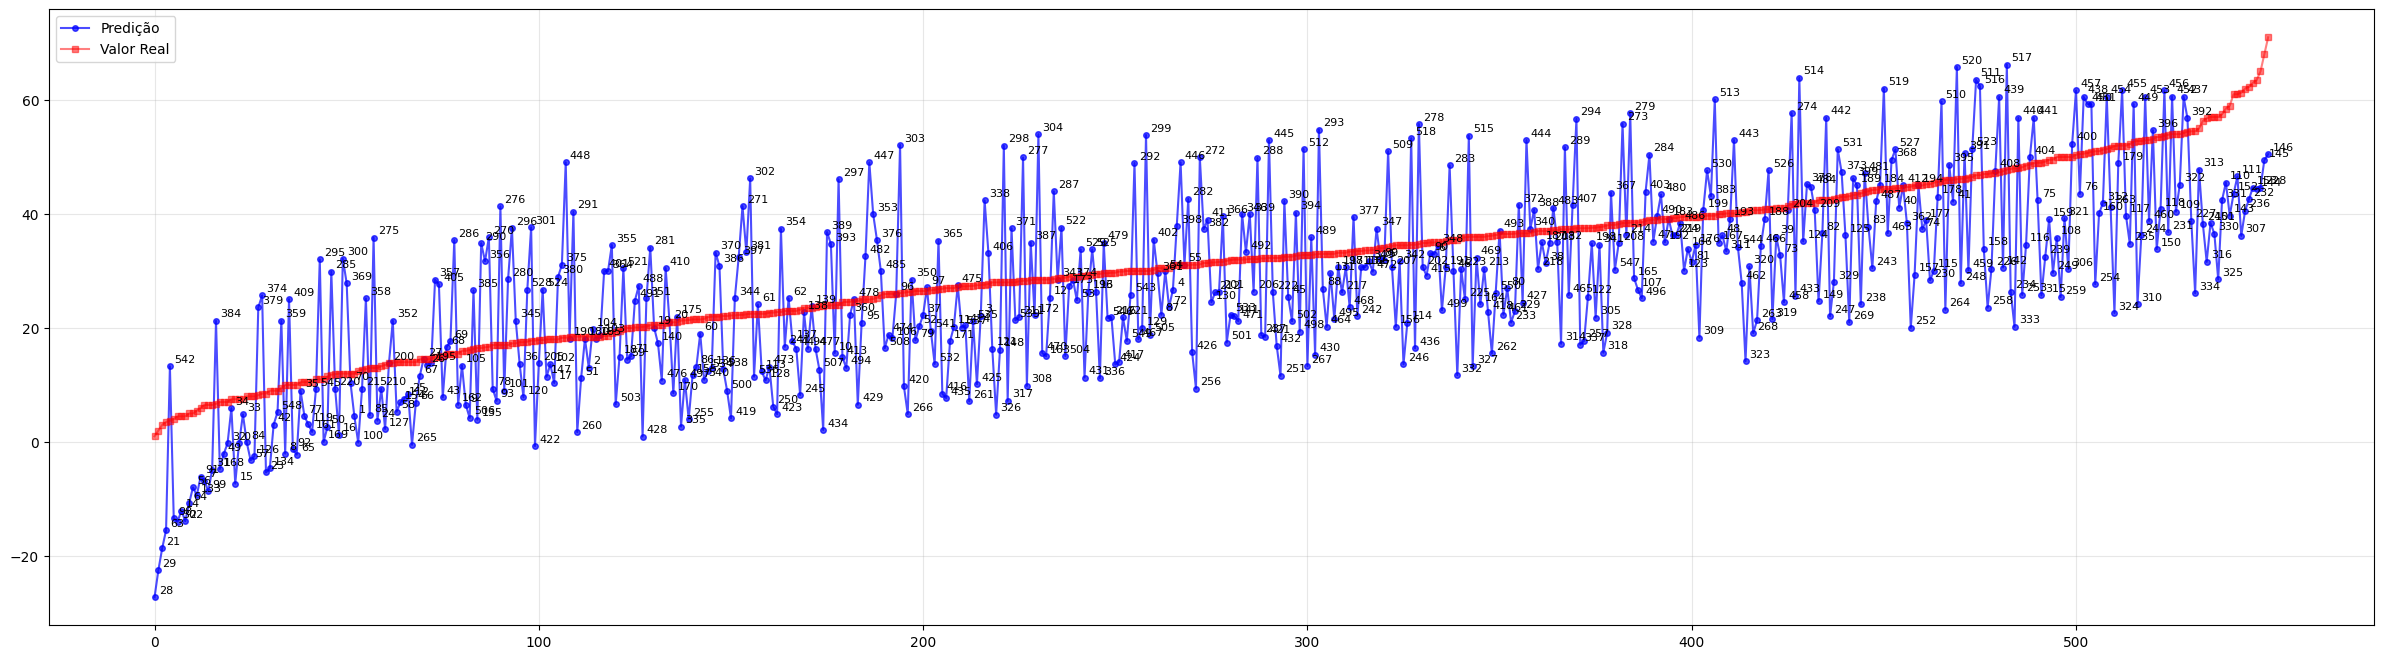

In [9]:
# Ordenando pelo valor real para a linha de predição não virar um "zigue-zague"
debug_df = lr_results.sort_values(by="y_true")
indices = range(len(debug_df))

plt.figure(figsize=(30, 8))

plt.plot(
    indices,
    debug_df["y_pred"],
    color='blue',
    label="Predição",
    alpha=0.7,
    linewidth=1.5,
    marker='o',
    markersize=4
)

plt.plot(
    indices,
    debug_df["y_true"],
    color='red',
    label="Valor Real",
    alpha=0.5,
    linewidth=1.5,
    marker='s',
    markersize=4
)

for x, y, idx in zip(
    indices,
    debug_df["y_pred"],
    debug_df.index
):
    plt.annotate(
        str(idx),
        (x, y),
        xytext=(3, 3),
        textcoords="offset points",
        fontsize=8
    )

plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Distribuição dos residuos

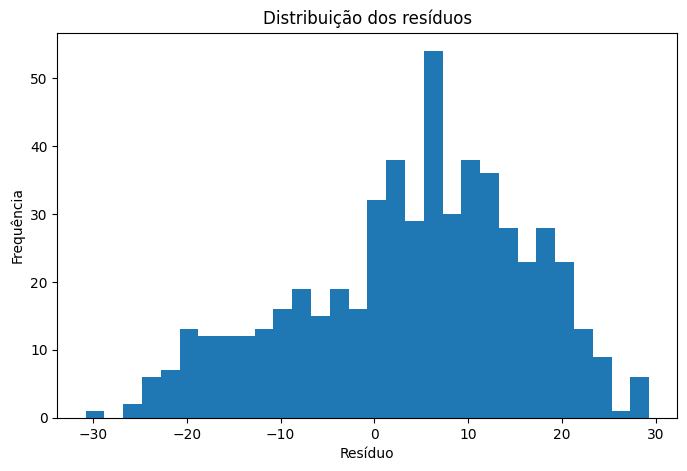

In [10]:
plt.figure(figsize=(8,5))

plt.hist(
    lr_results["residual"],
    bins=30
)

plt.xlabel("Resíduo")
plt.ylabel("Frequência")
plt.title("Distribuição dos resíduos")
plt.show()

## Residuo vs Predito

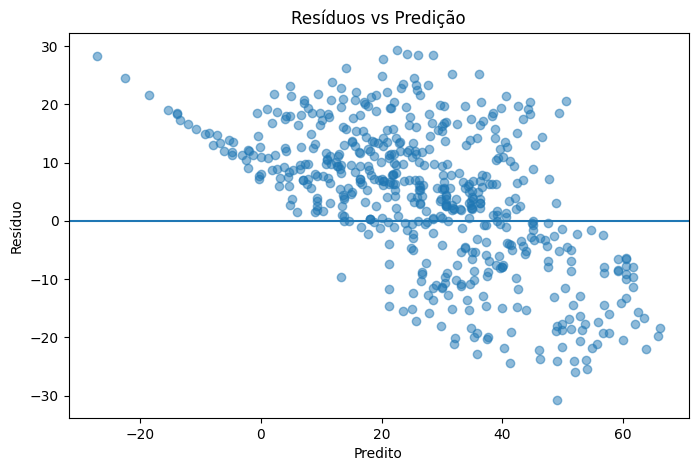

In [11]:
plt.figure(figsize=(8,5))

plt.scatter(
    lr_results["y_pred"],
    lr_results["residual"],
    alpha=0.5
)

plt.axhline(0)

plt.xlabel("Predito")
plt.ylabel("Resíduo")
plt.title("Resíduos vs Predição")
plt.show()

## Erro Medio por grupo

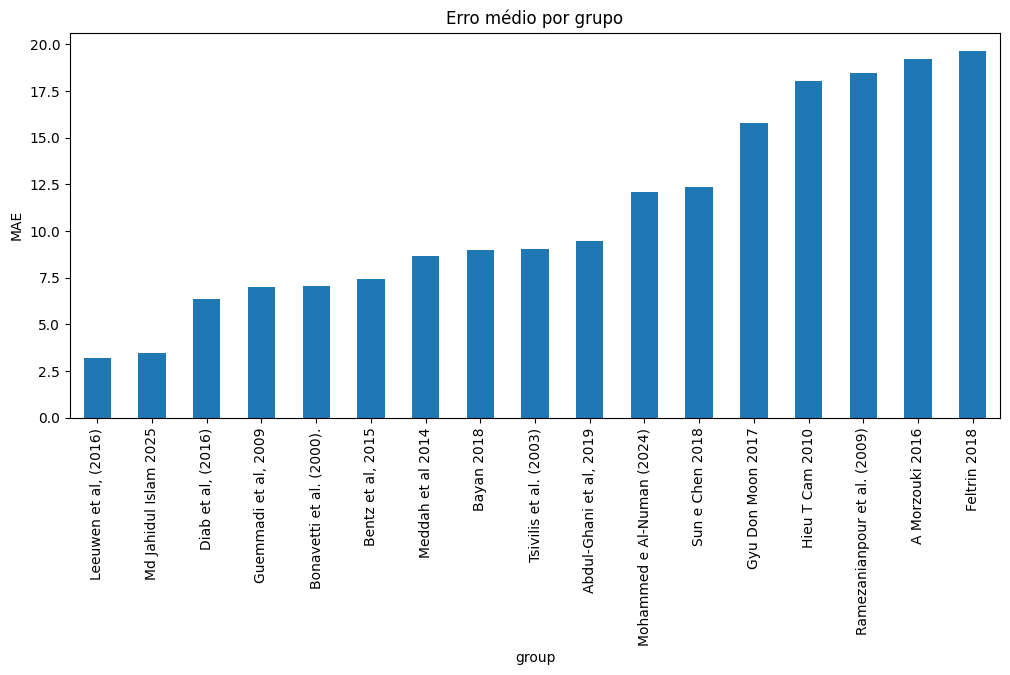

In [12]:
group_errors = (
    lr_results
    .groupby("group")
    ["abs_error"]
    .mean()
    .sort_values()
)
plt.figure(figsize=(12,5))

group_errors.plot(kind="bar")

plt.ylabel("MAE")
plt.title("Erro médio por grupo")
plt.show()

In [13]:
r2 = r2_score(debug_df["y_true"], debug_df["y_pred"])
rmse = root_mean_squared_error(debug_df["y_true"], debug_df["y_pred"])
mae = mean_absolute_error(debug_df["y_true"], debug_df["y_pred"])
mape = mean_absolute_percentage_error(debug_df["y_true"], debug_df["y_pred"])

print(f"root_mean_squared_error: {rmse:.4f}")
print(f"mean_absolute_error: {mae:.4f}")
print(f"mean_absolute_percentage_error: {mape:.4f}")
print(f"R² Score: {(r2*100):.4f}")

root_mean_squared_error: 12.7540
mean_absolute_error: 10.7200
mean_absolute_percentage_error: 0.5485
R² Score: 12.8373


# Teste com regressão Lasso

In [14]:
X = df_lasso.drop(
    columns=["target", "Autores/ano"]
)

y = df_lasso["target"]
groups = df_lasso["Autores/ano"]

def objective(trial):
    rmse_scores = []

    alpha = trial.suggest_float("alpha", 0.01, 10)

    for fold, (train_idx, val_idx) in enumerate(
        gkf.split(X, y, groups)
    ):

        X_train = X.iloc[train_idx]
        X_val = X.iloc[val_idx]

        y_train = y.iloc[train_idx]
        y_val = y.iloc[val_idx]

        scaler = StandardScaler()

        X_train = scaler.fit_transform(X_train)
        X_val = scaler.transform(X_val)

        model = Lasso(alpha=alpha, random_state=42)

        model.fit(X_train, y_train)

        preds = model.predict(X_val)

        rmse = root_mean_squared_error(y_val, preds)
        rmse_scores.append(rmse)

    return np.mean(rmse_scores)


In [15]:
# ==========================================
# EXECUTANDO O ESTUDO
# ==========================================
n_trials = 250

pbar = tqdm(total=n_trials, desc="Otimizando Regressão Lasso")

def tqdm_callback(study, trial):
    pbar.update(1)
    pbar.set_postfix({
        "best_rmse": f"{study.best_value:.4f}"
    })

study_lasso = optuna.create_study(
    direction="minimize",
    study_name="Tuning_Concreto"
)

study_lasso.optimize(
    objective,
    n_trials=n_trials,
    callbacks=[tqdm_callback]
)

pbar.close()

print(f"Melhor RMSE alcançado (Cross-Validation): {study_lasso.best_value:.4f}")
print("Melhores Hiperparâmetros encontrados:")
for key, value in study_lasso.best_params.items():
    print(f"  '{key}': {value},")

Otimizando Regressão Lasso:   0%|          | 0/250 [00:00<?, ?it/s]

[I 2026-06-11 15:08:27,968] A new study created in memory with name: Tuning_Concreto
[I 2026-06-11 15:08:28,128] Trial 0 finished with value: 9.300912216411232 and parameters: {'alpha': 5.697418547104001}. Best is trial 0 with value: 9.300912216411232.
[I 2026-06-11 15:08:28,291] Trial 1 finished with value: 8.32437147557457 and parameters: {'alpha': 4.654131343052372}. Best is trial 1 with value: 8.32437147557457.
[I 2026-06-11 15:08:28,446] Trial 2 finished with value: 11.187569622633683 and parameters: {'alpha': 7.788811153864622}. Best is trial 1 with value: 8.32437147557457.
[I 2026-06-11 15:08:28,599] Trial 3 finished with value: 7.173514422928845 and parameters: {'alpha': 0.7002712654773059}. Best is trial 3 with value: 7.173514422928845.
[I 2026-06-11 15:08:28,749] Trial 4 finished with value: 6.853328820589878 and parameters: {'alpha': 2.714513174186252}. Best is trial 4 with value: 6.853328820589878.
[I 2026-06-11 15:08:28,904] Trial 5 finished with value: 7.275179432521847 a

Melhor RMSE alcançado (Cross-Validation): 6.5588
Melhores Hiperparâmetros encontrados:
  'alpha': 1.9047078145842946,


In [16]:
all_preds = []
all_true = []
all_groups = []

X = df_lasso.drop(
    columns=["target", "Autores/ano"]
)

y = df_lasso["target"]
groups = df_lasso["Autores/ano"]

for fold, (train_idx, val_idx) in enumerate(
    gkf.split(X, y, groups)
):

    X_train = X.iloc[train_idx]
    X_val = X.iloc[val_idx]

    y_train = y.iloc[train_idx]
    y_val = y.iloc[val_idx]

    scaler = StandardScaler()

    X_train = scaler.fit_transform(X_train)
    X_val = scaler.transform(X_val)

    model = Lasso(alpha=study_lasso.best_params["alpha"], random_state=42)

    model.fit(X_train, y_train)

    preds = model.predict(X_val)

    all_preds.extend(preds)
    all_true.extend(y_val)
    all_groups.extend(groups.iloc[val_idx])

In [17]:
lasso_results = pd.DataFrame({
    "y_true": all_true,
    "y_pred": all_preds,
    "group": all_groups
})

lasso_results["residual"] = (
    lasso_results["y_true"] -
    lasso_results["y_pred"]
)

lasso_results["abs_error"] = (
    lasso_results["residual"].abs()
)

## Observado vs Predito

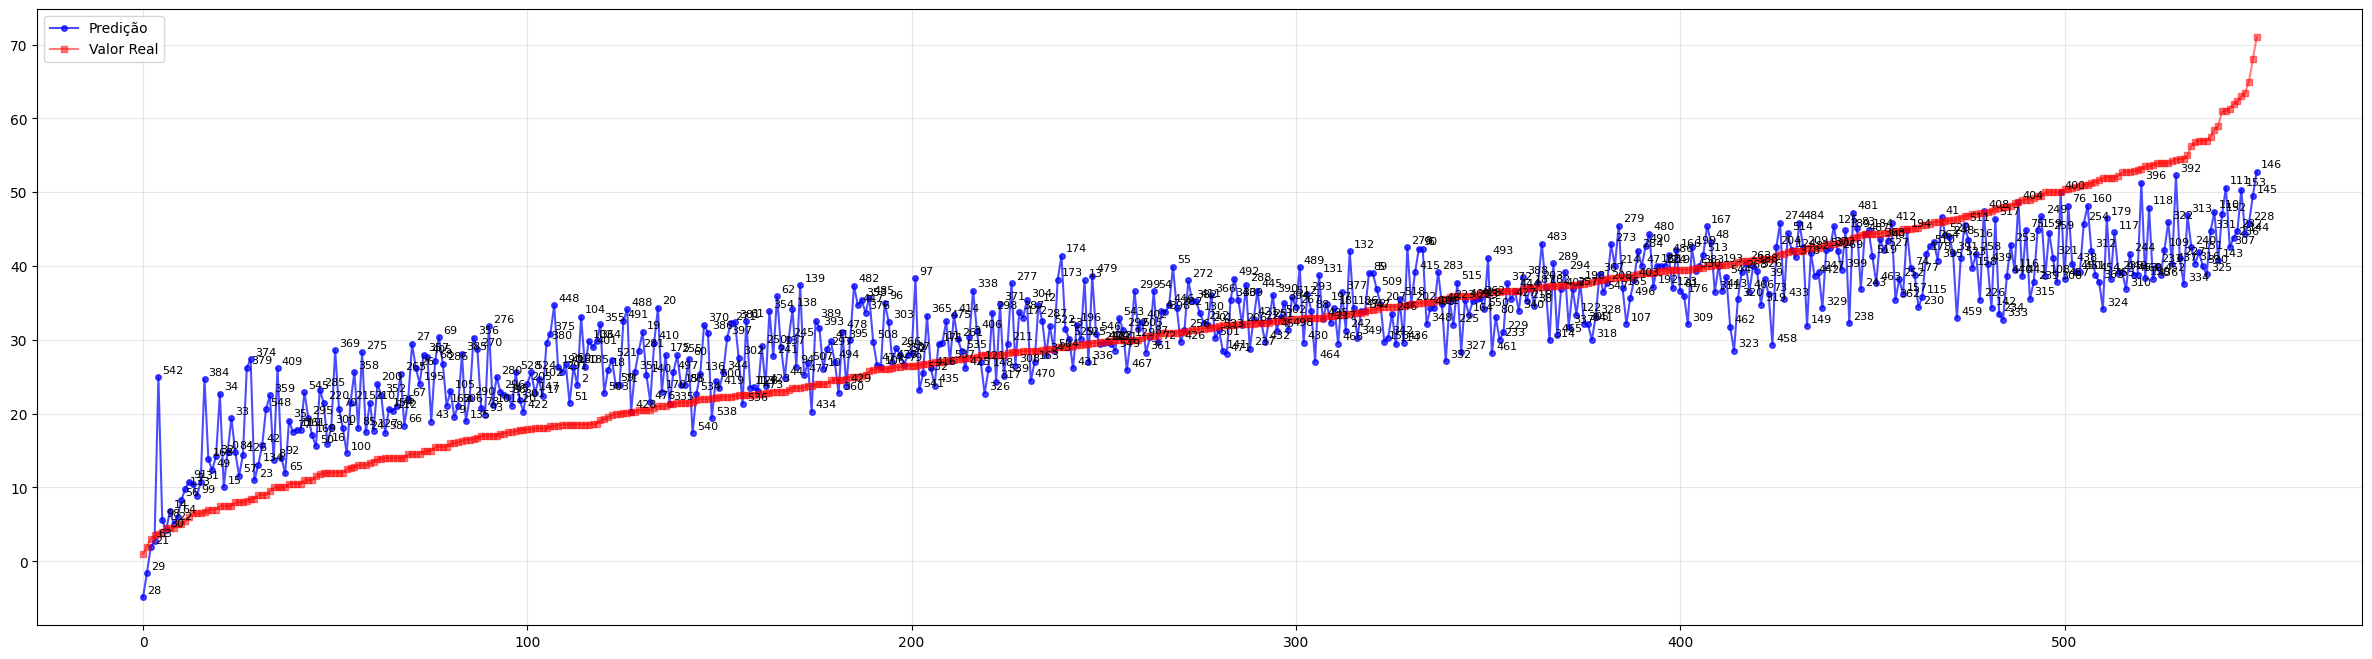

In [18]:
# Ordenando pelo valor real para a linha de predição não virar um "zigue-zague"
debug_df = lasso_results.sort_values(by="y_true")
indices = range(len(debug_df))

plt.figure(figsize=(30, 8))

plt.plot(
    indices,
    debug_df["y_pred"],
    color='blue',
    label="Predição",
    alpha=0.7,
    linewidth=1.5,
    marker='o',
    markersize=4
)

plt.plot(
    indices,
    debug_df["y_true"],
    color='red',
    label="Valor Real",
    alpha=0.5,
    linewidth=1.5,
    marker='s',
    markersize=4
)

for x, y, idx in zip(
    indices,
    debug_df["y_pred"],
    debug_df.index
):
    plt.annotate(
        str(idx),
        (x, y),
        xytext=(3, 3),
        textcoords="offset points",
        fontsize=8
    )

plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Distribuição dos residuos

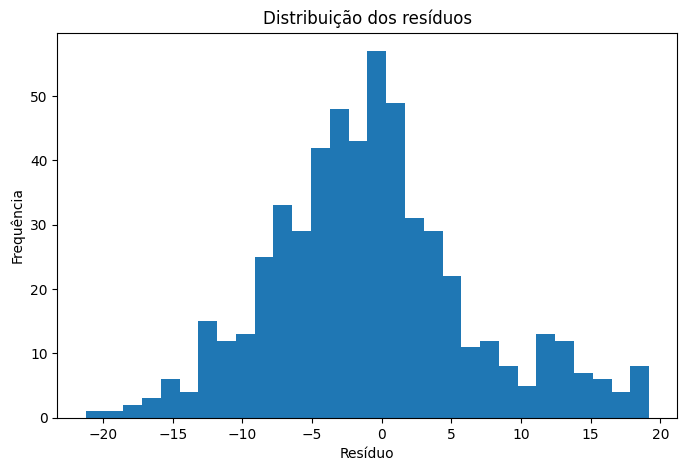

In [19]:
plt.figure(figsize=(8,5))

plt.hist(
    lasso_results["residual"],
    bins=30
)

plt.xlabel("Resíduo")
plt.ylabel("Frequência")
plt.title("Distribuição dos resíduos")
plt.show()

## Residuo vs Predito

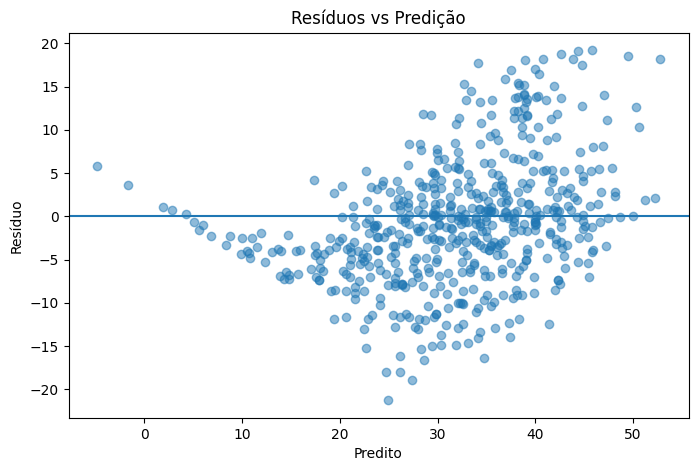

In [20]:
plt.figure(figsize=(8,5))

plt.scatter(
    lasso_results["y_pred"],
    lasso_results["residual"],
    alpha=0.5
)

plt.axhline(0)

plt.xlabel("Predito")
plt.ylabel("Resíduo")
plt.title("Resíduos vs Predição")
plt.show()

## Erro Medio por grupo

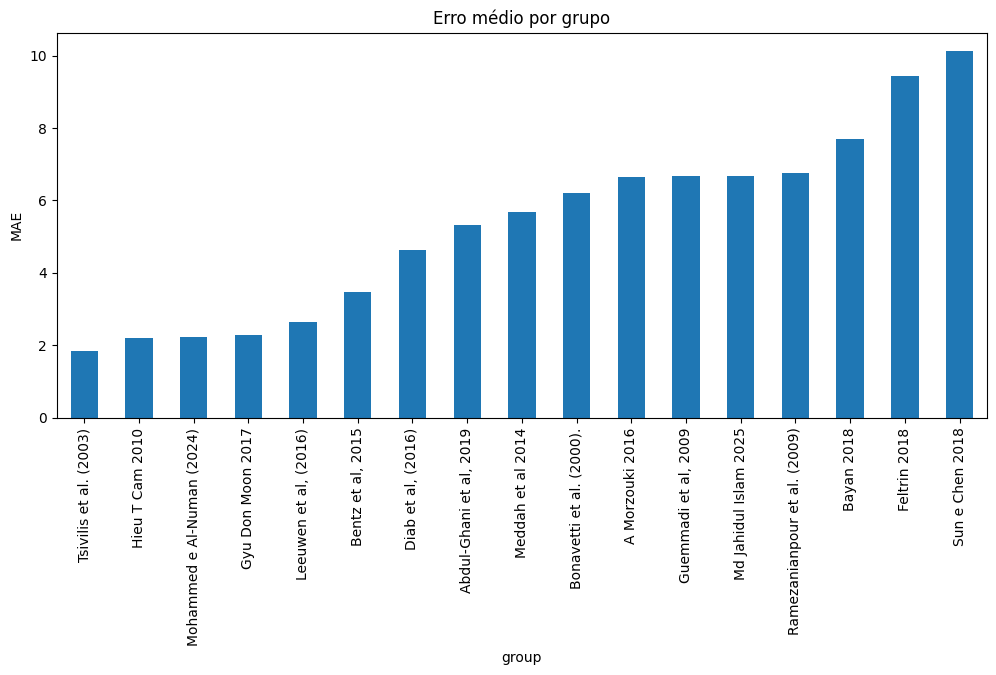

In [21]:
group_errors = (
    lasso_results
    .groupby("group")
    ["abs_error"]
    .mean()
    .sort_values()
)
plt.figure(figsize=(12,5))

group_errors.plot(kind="bar")

plt.ylabel("MAE")
plt.title("Erro médio por grupo")
plt.show()

In [22]:
r2 = r2_score(debug_df["y_true"], debug_df["y_pred"])
rmse = root_mean_squared_error(debug_df["y_true"], debug_df["y_pred"])
mae = mean_absolute_error(debug_df["y_true"], debug_df["y_pred"])
mape = mean_absolute_percentage_error(debug_df["y_true"], debug_df["y_pred"])

print(f"root_mean_squared_error: {rmse:.4f}")
print(f"mean_absolute_error: {mae:.4f}")
print(f"mean_absolute_percentage_error: {mape:.4f}")
print(f"R² Score: {(r2*100):.4f}")

root_mean_squared_error: 7.3252
mean_absolute_error: 5.6300
mean_absolute_percentage_error: 0.2692
R² Score: 71.2472


## Teste com regressão Ridge

In [23]:
X = df_ridge.drop(
    columns=["target", "Autores/ano"]
)

y = df_ridge["target"]
groups = df_ridge["Autores/ano"]

def objective(trial):
    rmse_scores = []

    alpha = trial.suggest_float("alpha", 0.01, 1000)

    for fold, (train_idx, val_idx) in enumerate(
        gkf.split(X, y, groups)
    ):

        X_train = X.iloc[train_idx]
        X_val = X.iloc[val_idx]

        y_train = y.iloc[train_idx]
        y_val = y.iloc[val_idx]

        scaler_train = StandardScaler()

        X_train = scaler_train.fit_transform(X_train)
        X_val = scaler_train.transform(X_val)

        model = Ridge(alpha=alpha, random_state=42)

        model.fit(X_train, y_train)

        preds = model.predict(X_val)

        rmse = root_mean_squared_error(y_val, preds)
        rmse_scores.append(rmse)

    return np.mean(rmse_scores)


In [24]:
# ==========================================
# EXECUTANDO O ESTUDO
# ==========================================
n_trials = 250

pbar = tqdm(total=n_trials, desc="Otimizando Regressão Ridge")

def tqdm_callback(study, trial):
    pbar.update(1)
    pbar.set_postfix({
        "best_rmse": f"{study.best_value:.4f}"
    })

study_ridge = optuna.create_study(
    direction="minimize",
    study_name="Tuning_Concreto"
)

study_ridge.optimize(
    objective,
    n_trials=n_trials,
    callbacks=[tqdm_callback]
)

pbar.close()

print(f"Melhor RMSE alcançado (Cross-Validation): {study_ridge.best_value:.4f}")
print("Melhores Hiperparâmetros encontrados:")
for key, value in study_ridge.best_params.items():
    print(f"  '{key}': {value},")

Otimizando Regressão Ridge:   0%|          | 0/250 [00:00<?, ?it/s]

[I 2026-06-11 15:09:14,944] A new study created in memory with name: Tuning_Concreto
[I 2026-06-11 15:09:15,177] Trial 0 finished with value: 8.544604095529165 and parameters: {'alpha': 947.1542003234986}. Best is trial 0 with value: 8.544604095529165.
[I 2026-06-11 15:09:15,384] Trial 1 finished with value: 8.419906190233714 and parameters: {'alpha': 18.906016288961588}. Best is trial 1 with value: 8.419906190233714.
[I 2026-06-11 15:09:15,580] Trial 2 finished with value: 8.137937872215542 and parameters: {'alpha': 605.2465302238736}. Best is trial 2 with value: 8.137937872215542.
[I 2026-06-11 15:09:15,771] Trial 3 finished with value: 7.778681261344681 and parameters: {'alpha': 304.27215725104986}. Best is trial 3 with value: 7.778681261344681.
[I 2026-06-11 15:09:15,971] Trial 4 finished with value: 7.793917614903194 and parameters: {'alpha': 319.0078377760467}. Best is trial 3 with value: 7.778681261344681.
[I 2026-06-11 15:09:16,183] Trial 5 finished with value: 7.96578139639496

Melhor RMSE alcançado (Cross-Validation): 7.6267
Melhores Hiperparâmetros encontrados:
  'alpha': 104.76839433187078,


In [25]:
all_instances = []

X = df_ridge.drop(
    columns=["target", "Autores/ano"]
)

y = df_ridge["target"]
groups = df_ridge["Autores/ano"]

for fold, (train_idx, val_idx) in enumerate(
    gkf.split(X, y, groups)
):

    X_train = X.iloc[train_idx]
    X_val = X.iloc[val_idx]

    y_train = y.iloc[train_idx]
    y_val = y.iloc[val_idx]

    scaler = StandardScaler()

    X_train = scaler.fit_transform(X_train)
    X_val = scaler.transform(X_val)

    model = Ridge(alpha=study_ridge.best_params["alpha"], random_state=42)

    model.fit(X_train, y_train)

    preds = model.predict(X_val)

    fold_results = df_ridge.iloc[val_idx].copy()

    fold_results["y_true"] = y_val.values
    fold_results["y_pred"] = preds
    fold_results["error"] = (
        fold_results["y_true"] - fold_results["y_pred"]
    )
    fold_results["abs_error"] = (
        fold_results["error"].abs()
    )
    fold_results["group"] = groups.iloc[val_idx].values

    all_instances.append(fold_results)

In [26]:
all_instances[0].columns

Index(['Autores/ano', 'Massa_Esp_Cimento_g_cm3', 'Finura_Cimento_Blaine_m2_kg',
       'Massa_Esp_Filer_g_cm3', 'Massa_Esp_Areia_g_cm3',
       'Massa_Esp_Brita_g_cm3', 'Cimento_kg_m3', 'Filer_Calcario_kg_m3',
       'Agua_kg_m3', 'Agregado_Miudo_Total_kg_m3',
       'Agregado_Graudo_Total_kg_m3', 'Superplastificante_kg_m3',
       'Relacao_Agua_Cimento', 'idade', 'ln_Idade', 'Tipo_Molde_Cod',
       'Metodo_Emp_Cod', 'Usa_SP', 'Classe_Cim_OpA',
       'Relacao_Agua_Aglomerante', 'Filer_D50_um', 'D_Max', 'cod_classe',
       'target', 'y_true', 'y_pred', 'error', 'abs_error', 'group'],
      dtype='object')

In [27]:
ridge_results = pd.concat(all_instances, ignore_index=True)

debug_df['error'] = (
    debug_df['y_true'] - debug_df['y_pred']
)

debug_df['abs_error'] = (
    debug_df['error'].abs()
)

ridge_results["residual"] = (
    ridge_results["y_true"] -
    ridge_results["y_pred"]
)

ridge_results["abs_error"] = (
    ridge_results["residual"].abs()
)

## Observado vs Predito

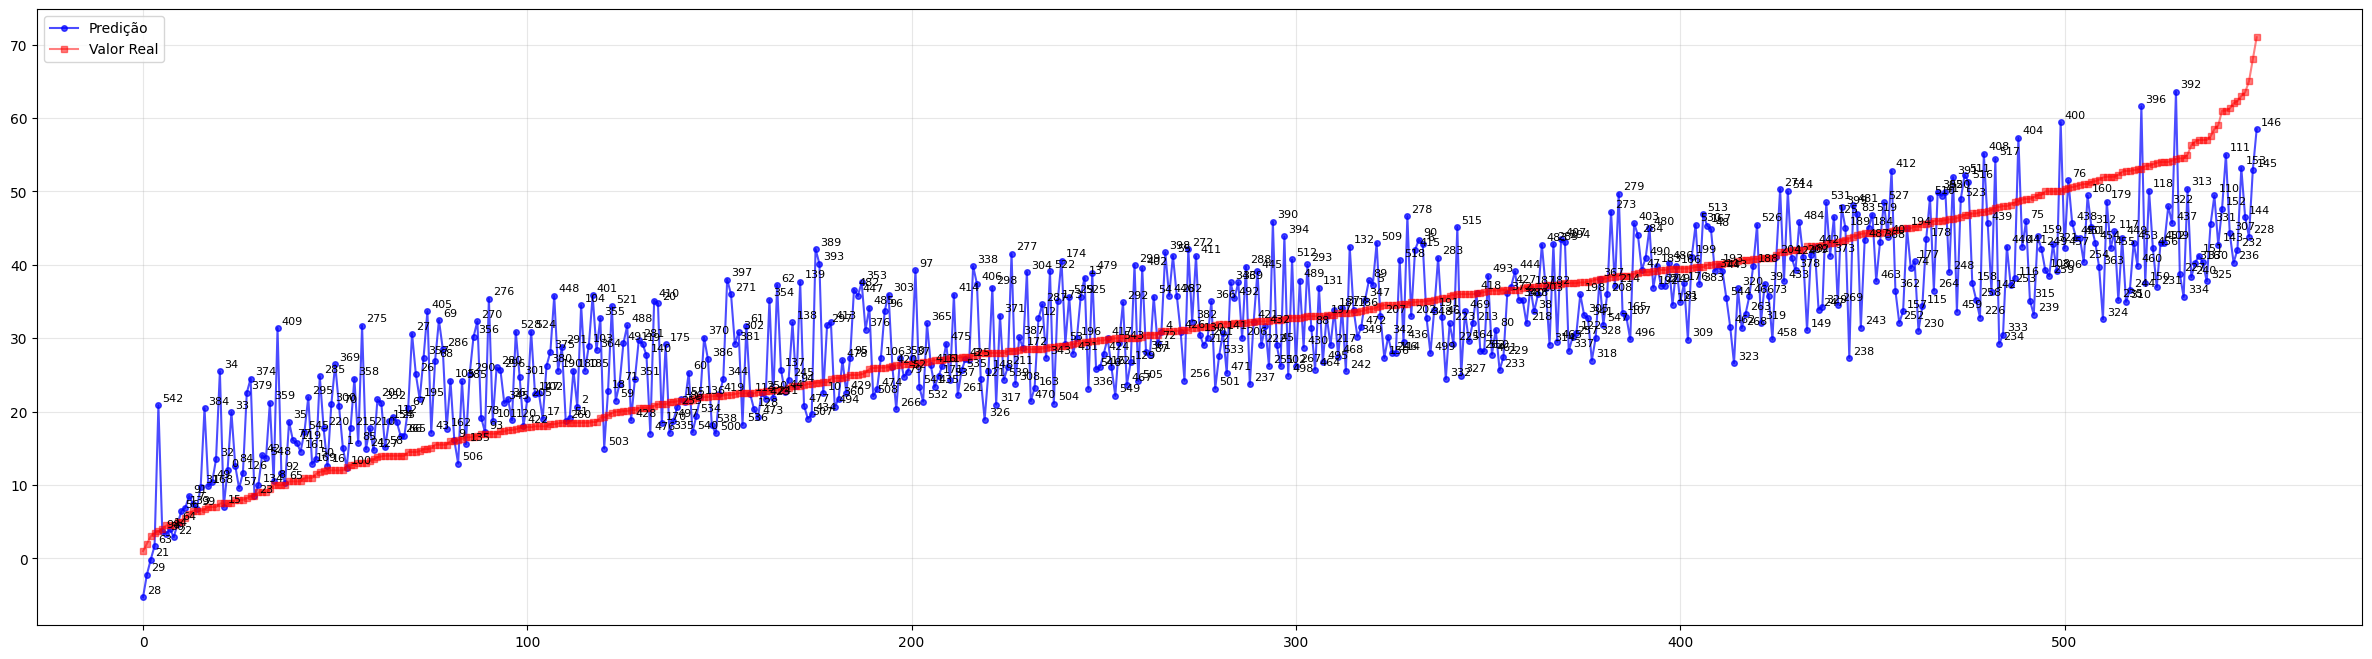

In [28]:
# Ordenando pelo valor real para a linha de predição não virar um "zigue-zague"
debug_df = ridge_results.sort_values(by="y_true")
indices = range(len(debug_df))

plt.figure(figsize=(30, 8))

plt.plot(
    indices,
    debug_df["y_pred"],
    color='blue',
    label="Predição",
    alpha=0.7,
    linewidth=1.5,
    marker='o',
    markersize=4
)

plt.plot(
    indices,
    debug_df["y_true"],
    color='red',
    label="Valor Real",
    alpha=0.5,
    linewidth=1.5,
    marker='s',
    markersize=4
)

for x, y, idx in zip(
    indices,
    debug_df["y_pred"],
    debug_df.index
):
    plt.annotate(
        str(idx),
        (x, y),
        xytext=(3, 3),
        textcoords="offset points",
        fontsize=8
    )

plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Distribuição dos residuos

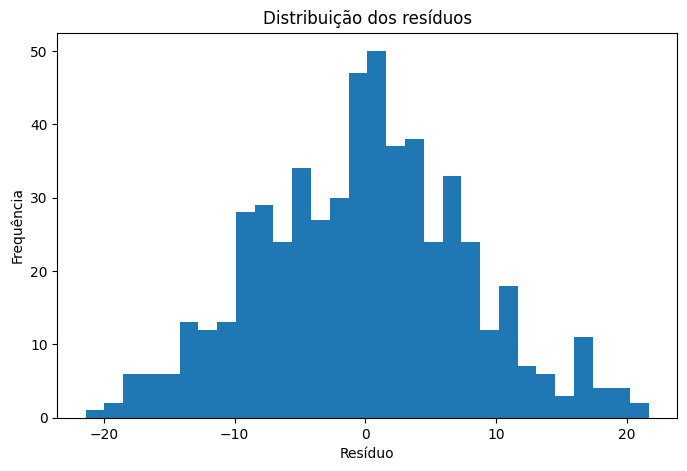

In [29]:
plt.figure(figsize=(8,5))

plt.hist(
    ridge_results["residual"],
    bins=30
)

plt.xlabel("Resíduo")
plt.ylabel("Frequência")
plt.title("Distribuição dos resíduos")
plt.show()

In [30]:
debug_df.columns

Index(['Autores/ano', 'Massa_Esp_Cimento_g_cm3', 'Finura_Cimento_Blaine_m2_kg',
       'Massa_Esp_Filer_g_cm3', 'Massa_Esp_Areia_g_cm3',
       'Massa_Esp_Brita_g_cm3', 'Cimento_kg_m3', 'Filer_Calcario_kg_m3',
       'Agua_kg_m3', 'Agregado_Miudo_Total_kg_m3',
       'Agregado_Graudo_Total_kg_m3', 'Superplastificante_kg_m3',
       'Relacao_Agua_Cimento', 'idade', 'ln_Idade', 'Tipo_Molde_Cod',
       'Metodo_Emp_Cod', 'Usa_SP', 'Classe_Cim_OpA',
       'Relacao_Agua_Aglomerante', 'Filer_D50_um', 'D_Max', 'cod_classe',
       'target', 'y_true', 'y_pred', 'error', 'abs_error', 'group',
       'residual'],
      dtype='object')

## Residuo vs Predito

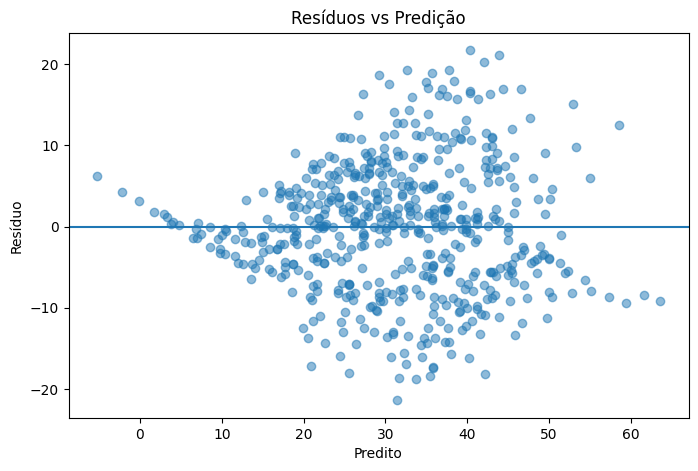

In [31]:
plt.figure(figsize=(8,5))

plt.scatter(
    ridge_results["y_pred"],
    ridge_results["residual"],
    alpha=0.5
)

plt.axhline(0)

plt.xlabel("Predito")
plt.ylabel("Resíduo")
plt.title("Resíduos vs Predição")
plt.show()

## Erro Medio por grupo

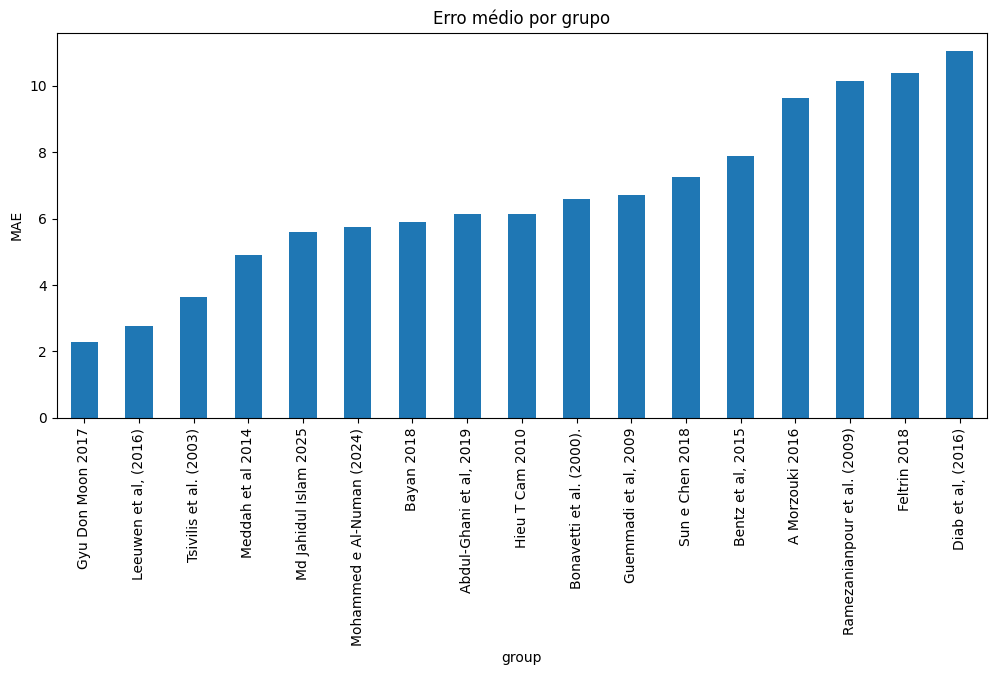

In [32]:
group_errors = (
    ridge_results
    .groupby("group")
    ["abs_error"]
    .mean()
    .sort_values()
)
plt.figure(figsize=(12,5))

group_errors.plot(kind="bar")

plt.ylabel("MAE")
plt.title("Erro médio por grupo")
plt.show()

In [33]:
top_erros = (
    debug_df
    .query("abs_error > 15")
    .sort_values("abs_error", ascending=False)
)

display(top_erros)

,Autores/ano,Massa_Esp_Cimento_g_cm3,Finura_Cimento_Blaine_m2_kg,Massa_Esp_Filer_g_cm3,Massa_Esp_Areia_g_cm3,Massa_Esp_Brita_g_cm3,Cimento_kg_m3,Filer_Calcario_kg_m3,Agua_kg_m3,Agregado_Miudo_Total_kg_m3,...,Filer_D50_um,D_Max,cod_classe,target,y_true,y_pred,error,abs_error,group,residual
236,Ramezanianpour et al. (2009),3.21,320.0,2.69,2.57,2.51,315.0,35.0,129.5,960.0,...,0.0,19.0,0,62.00,62.00,40.285295,21.714705,21.714705,Ramezanianpour et al. (2009),21.714705
409,"Diab et al, (2016)",3.14,381.0,2.55,2.61,2.57,300.0,100.0,183.0,707.0,...,0.0,20.0,18,10.00,10.00,31.393657,-21.393657,21.393657,"Diab et al, (2016)",-21.393657
228,Ramezanianpour et al. (2009),3.21,320.0,2.69,2.57,2.51,350.0,0.0,129.5,960.0,...,0.0,19.0,0,65.00,65.00,43.856527,21.143473,21.143473,Ramezanianpour et al. (2009),21.143473
232,Ramezanianpour et al. (2009),3.21,320.0,2.69,2.57,2.51,332.5,17.5,129.5,960.0,...,0.0,19.0,0,62.30,62.30,42.071014,20.228986,20.228986,Ramezanianpour et al. (2009),20.228986
324,Feltrin 2018,3.09,381.0,2.89,2.65,2.65,306.0,54.0,183.0,741.0,...,0.0,20.0,10,51.90,51.90,32.599851,19.300149,19.300149,Feltrin 2018,19.300149
325,Feltrin 2018,3.09,381.0,2.89,2.65,2.65,306.0,54.0,183.0,741.0,...,0.0,20.0,10,57.00,57.00,37.769881,19.230119,19.230119,Feltrin 2018,19.230119
334,Feltrin 2018,3.09,381.0,2.89,2.65,2.65,288.0,72.0,183.0,741.0,...,0.0,20.0,10,54.50,54.50,35.629068,18.870932,18.870932,Feltrin 2018,18.870932
405,"Diab et al, (2016)",3.14,381.0,2.55,2.61,2.57,320.0,80.0,183.0,708.0,...,0.0,20.0,18,14.90,14.90,33.701872,-18.801872,18.801872,"Diab et al, (2016)",-18.801872
275,A Morzouki 2016,3.04,264.0,2.70,2.61,2.57,334.4,17.6,190.0,607.0,...,0.0,20.0,8,13.00,13.00,31.703325,-18.703325,18.703325,A Morzouki 2016,-18.703325
234,Ramezanianpour et al. (2009),3.21,320.0,2.69,2.57,2.51,315.0,35.0,129.5,960.0,...,0.0,19.0,0,47.90,47.90,29.251036,18.648964,18.648964,Ramezanianpour et al. (2009),18.648964


In [34]:
r2 = r2_score(debug_df["y_true"], debug_df["y_pred"])
rmse = root_mean_squared_error(debug_df["y_true"], debug_df["y_pred"])
mae = mean_absolute_error(debug_df["y_true"], debug_df["y_pred"])
mape = mean_absolute_percentage_error(debug_df["y_true"], debug_df["y_pred"])

print(f"root_mean_squared_error: {rmse:.4f}")
print(f"mean_absolute_error: {mae:.4f}")
print(f"mean_absolute_percentage_error: {mape:.4f}")
print(f"R² Score: {(r2*100):.4f}")

root_mean_squared_error: 7.9811
mean_absolute_error: 6.3172
mean_absolute_percentage_error: 0.2724
R² Score: 65.8682


## Teste com ElasticNet

In [35]:
X = df_elasticnet.drop(
    columns=["target", "Autores/ano"]
)

y = df_elasticnet["target"]
groups = df_elasticnet["Autores/ano"]

def objective(trial):
    rmse_scores = []

    hyperparams = {
        "alpha": trial.suggest_float("alpha", 0.01, 10),
        "l1_ratio": trial.suggest_float("l1_ratio", 0.01, 1.0)
    }

    for fold, (train_idx, val_idx) in enumerate(
        gkf.split(X, y, groups)
    ):

        X_train = X.iloc[train_idx]
        X_val = X.iloc[val_idx]

        y_train = y.iloc[train_idx]
        y_val = y.iloc[val_idx]

        scaler = StandardScaler()

        X_train = scaler.fit_transform(X_train)
        X_val = scaler.transform(X_val)

        model = ElasticNet(**hyperparams, random_state=42)

        model.fit(X_train, y_train)

        preds = model.predict(X_val)

        rmse = root_mean_squared_error(y_val, preds)
        rmse_scores.append(rmse)

    return np.mean(rmse_scores)


In [36]:
# ==========================================
# EXECUTANDO O ESTUDO
# ==========================================
n_trials = 100

pbar = tqdm(total=n_trials, desc="Otimizando Regressão ElasticNet")

def tqdm_callback(study, trial):
    pbar.update(1)
    pbar.set_postfix({
        "best_rmse": f"{study.best_value:.4f}"
    })

study_elasticnet = optuna.create_study(
    direction="minimize",
    study_name="Tuning_Concreto"
)

study_elasticnet.optimize(
    objective,
    n_trials=n_trials,
    callbacks=[tqdm_callback]
)

pbar.close()

print(f"Melhor RMSE alcançado (Cross-Validation): {study_elasticnet.best_value:.4f}")
print("Melhores Hiperparâmetros encontrados:")
for key, value in study_elasticnet.best_params.items():
    print(f"  '{key}': {value},")

Otimizando Regressão ElasticNet:   0%|          | 0/100 [00:00<?, ?it/s]

[I 2026-06-11 15:10:01,737] A new study created in memory with name: Tuning_Concreto
[I 2026-06-11 15:10:01,990] Trial 0 finished with value: 7.3456905019505925 and parameters: {'alpha': 3.1543865034326717, 'l1_ratio': 0.9625341679949896}. Best is trial 0 with value: 7.3456905019505925.
[I 2026-06-11 15:10:02,205] Trial 1 finished with value: 9.679306169161197 and parameters: {'alpha': 5.624445085625815, 'l1_ratio': 0.7868808346921494}. Best is trial 0 with value: 7.3456905019505925.
[I 2026-06-11 15:10:02,429] Trial 2 finished with value: 10.240634584340285 and parameters: {'alpha': 6.873820214361169, 'l1_ratio': 0.6124326872923658}. Best is trial 0 with value: 7.3456905019505925.
[I 2026-06-11 15:10:02,647] Trial 3 finished with value: 7.422346600043844 and parameters: {'alpha': 0.7872524689376231, 'l1_ratio': 0.6309813542985656}. Best is trial 0 with value: 7.3456905019505925.
[I 2026-06-11 15:10:02,859] Trial 4 finished with value: 10.07139239174716 and parameters: {'alpha': 7.0880

Melhor RMSE alcançado (Cross-Validation): 6.5631
Melhores Hiperparâmetros encontrados:
  'alpha': 1.9096154680389883,
  'l1_ratio': 0.9989787964304943,


In [37]:
all_preds = []
all_true = []
all_groups = []

X = df_elasticnet.drop(
    columns=["target", "Autores/ano"]
)

y = df_elasticnet["target"]
groups = df_elasticnet["Autores/ano"]

for fold, (train_idx, val_idx) in enumerate(
    gkf.split(X, y, groups)
):

    X_train = X.iloc[train_idx]
    X_val = X.iloc[val_idx]

    y_train = y.iloc[train_idx]
    y_val = y.iloc[val_idx]

    scaler = StandardScaler()

    X_train = scaler.fit_transform(X_train)
    X_val = scaler.transform(X_val)

    model = ElasticNet(**study_elasticnet.best_params, random_state=42)

    model.fit(X_train, y_train)

    preds = model.predict(X_val)

    all_preds.extend(preds)
    all_true.extend(y_val)
    all_groups.extend(groups.iloc[val_idx])

In [38]:
elasticnet_results = pd.DataFrame({
    "y_true": all_true,
    "y_pred": all_preds,
    "group": all_groups
})

elasticnet_results["residual"] = (
    elasticnet_results["y_true"] -
    elasticnet_results["y_pred"]
)

elasticnet_results["abs_error"] = (
    elasticnet_results["residual"].abs()
)

## Observado vs Predito

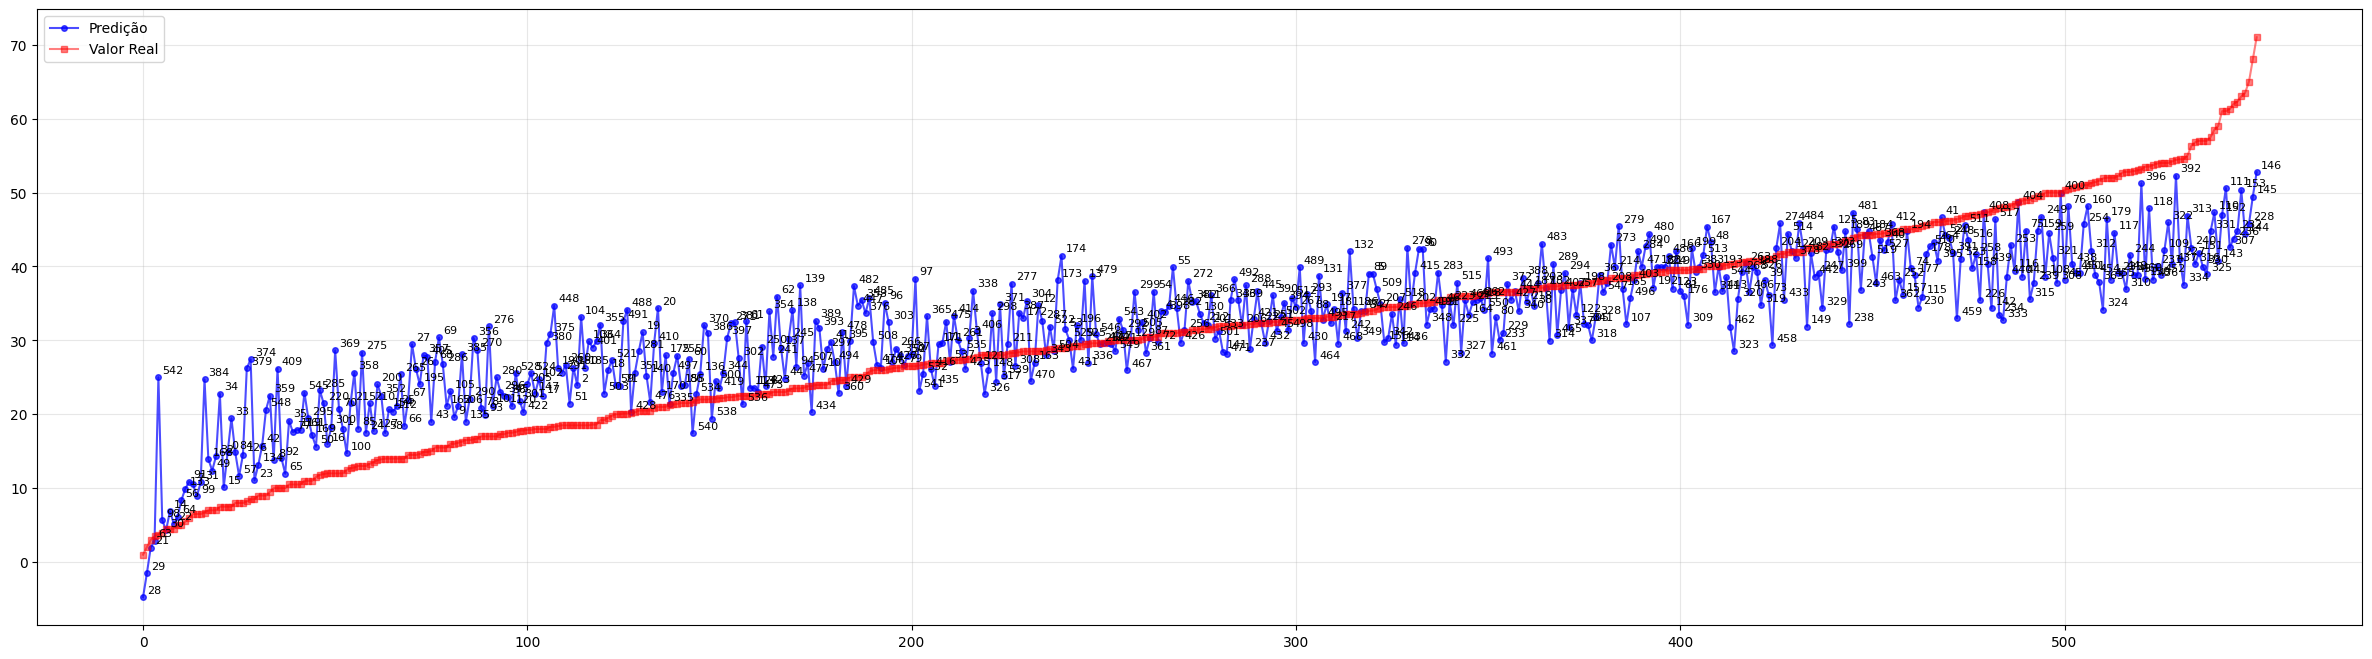

In [39]:
# Ordenando pelo valor real para a linha de predição não virar um "zigue-zague"
debug_df = elasticnet_results.sort_values(by="y_true")
indices = range(len(debug_df))

plt.figure(figsize=(30, 8))

plt.plot(
    indices,
    debug_df["y_pred"],
    color='blue',
    label="Predição",
    alpha=0.7,
    linewidth=1.5,
    marker='o',
    markersize=4
)

plt.plot(
    indices,
    debug_df["y_true"],
    color='red',
    label="Valor Real",
    alpha=0.5,
    linewidth=1.5,
    marker='s',
    markersize=4
)

for x, y, idx in zip(
    indices,
    debug_df["y_pred"],
    debug_df.index
):
    plt.annotate(
        str(idx),
        (x, y),
        xytext=(3, 3),
        textcoords="offset points",
        fontsize=8
    )

plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Distribuição dos residuos

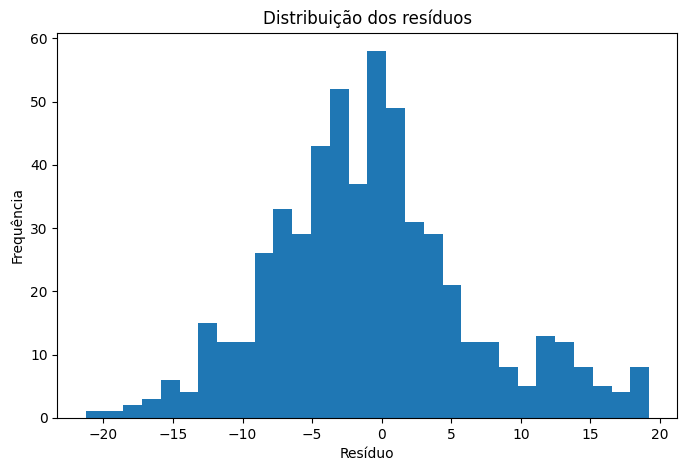

In [40]:
plt.figure(figsize=(8,5))

plt.hist(
    elasticnet_results["residual"],
    bins=30
)

plt.xlabel("Resíduo")
plt.ylabel("Frequência")
plt.title("Distribuição dos resíduos")
plt.show()

## Residuo vs Predito

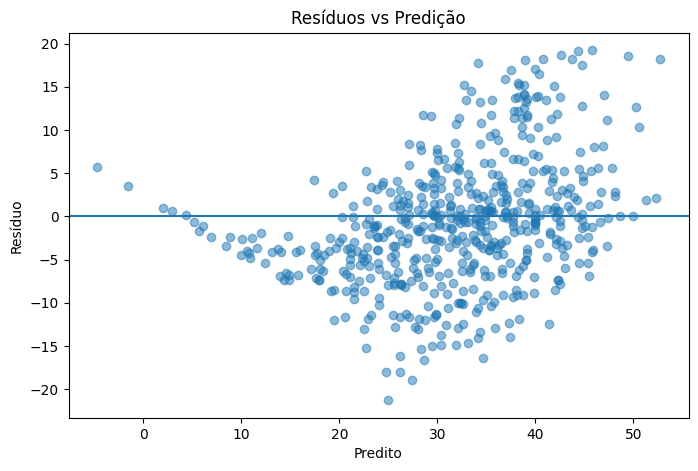

In [41]:
plt.figure(figsize=(8,5))

plt.scatter(
    elasticnet_results["y_pred"],
    elasticnet_results["residual"],
    alpha=0.5
)

plt.axhline(0)

plt.xlabel("Predito")
plt.ylabel("Resíduo")
plt.title("Resíduos vs Predição")
plt.show()

## Erro Medio por grupo

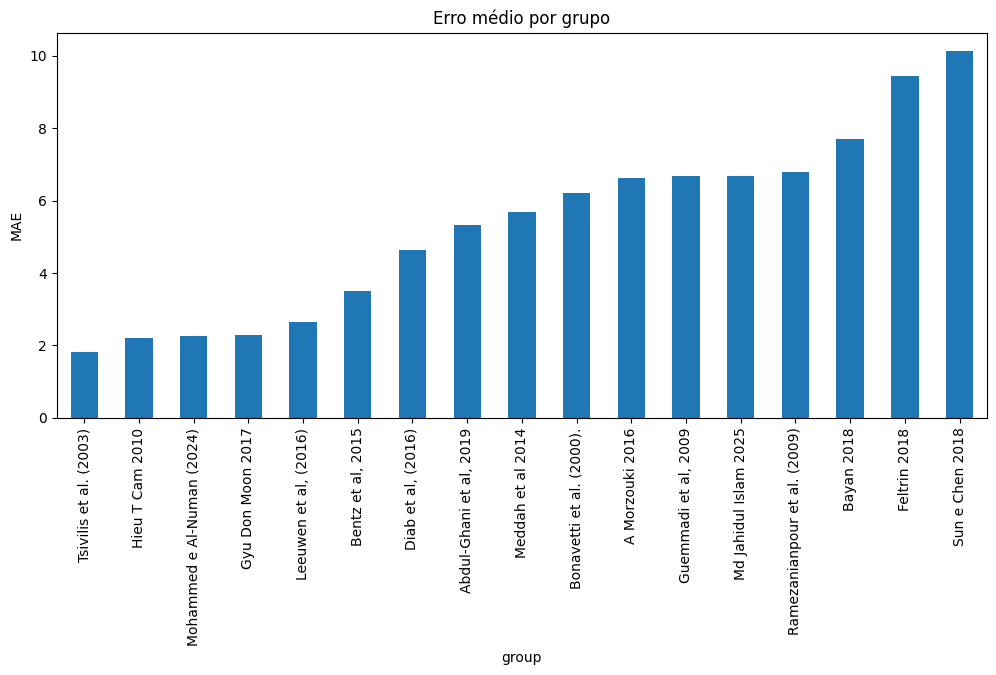

In [42]:
group_errors = (
    elasticnet_results
    .groupby("group")
    ["abs_error"]
    .mean()
    .sort_values()
)
plt.figure(figsize=(12,5))

group_errors.plot(kind="bar")

plt.ylabel("MAE")
plt.title("Erro médio por grupo")
plt.show()

In [43]:
r2 = r2_score(debug_df["y_true"], debug_df["y_pred"])
rmse = root_mean_squared_error(debug_df["y_true"], debug_df["y_pred"])
mae = mean_absolute_error(debug_df["y_true"], debug_df["y_pred"])
mape = mean_absolute_percentage_error(debug_df["y_true"], debug_df["y_pred"])

print(f"root_mean_squared_error: {rmse:.4f}")
print(f"mean_absolute_error: {mae:.4f}")
print(f"mean_absolute_percentage_error: {mape:.4f}")
print(f"R² Score: {(r2*100):.4f}")

root_mean_squared_error: 7.3334
mean_absolute_error: 5.6379
mean_absolute_percentage_error: 0.2696
R² Score: 71.1828
